In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [81]:
os.getcwd()

'/Users/zoetankersley/sunrise_social_club/notebooks'

In [82]:
df=pd.read_csv('/Users/zoetankersley/sunrise_social_club/data/processed/sales_may_merged.csv')

In [83]:
df.head()

,Date,Time,Time Zone,Category,Item,Qty,Price Point Name,SKU,Modifiers Applied,Gross Sales,...,Itemization Type,Fulfillment Note,Channel,Token,Card Brand,PAN Suffix,Avg_Temp,Weather_Condition,Event_Type,Location_y
0,2026-05-30,13:03:14,Eastern Time (US & Canada),NaN,sticker,1.0,Regular,NaN,NaN,$2.00,...,Physical Good,NaN,Sunrise Social Club LLC,WIKDKPJ6J74CB44HCJ6NMKSX,Visa,7608.0,79.0,Sunny,Market,Manteo
1,2026-05-30,13:00:57,Eastern Time (US & Canada),NaN,Cold Brew,1.0,Regular,NaN,"Blueberry, Cold Foam",$7.00,...,Physical Good,NaN,Sunrise Social Club LLC,AJEX3MBMC7CMJ6SCA7D4RJIK,Visa,7608.0,79.0,Sunny,Market,Manteo
2,2026-05-30,12:46:22,Eastern Time (US & Canada),NaN,Matcha Latte,1.0,NaN,NaN,"Vanilla, 16oz",$8.00,...,Physical Good,NaN,Sunrise Social Club LLC,Y36H4C6V4YFFYACS3RIEFARY,NaN,NaN,79.0,Sunny,Market,Manteo
3,2026-05-30,12:39:40,Eastern Time (US & Canada),NaN,Matcha Latte,1.0,NaN,NaN,Strawberry,$7.00,...,Physical Good,NaN,Sunrise Social Club LLC,Y36H4C6V4YFFYACS3RIEFARY,NaN,NaN,79.0,Sunny,Market,Manteo
4,2026-05-30,12:39:40,Eastern Time (US & Canada),NaN,Matcha Latte,1.0,NaN,NaN,Cake Batter,$7.00,...,Physical Good,NaN,Sunrise Social Club LLC,Y36H4C6V4YFFYACS3RIEFARY,NaN,NaN,79.0,Sunny,Market,Manteo


In [84]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Date                   223 non-null    object 
 1   Time                   223 non-null    object 
 2   Time Zone              223 non-null    object 
 3   Category               0 non-null      float64
 4   Item                   223 non-null    object 
 5   Qty                    223 non-null    float64
 6   Price Point Name       83 non-null     object 
 7   SKU                    0 non-null      float64
 8   Modifiers Applied      199 non-null    object 
 9   Gross Sales            223 non-null    object 
 10  Discounts              223 non-null    object 
 11  Net Sales              223 non-null    object 
 12  Tax                    223 non-null    object 
 13  Transaction ID         223 non-null    object 
 14  Payment ID             223 non-null    object 
 15  Device

In [85]:
df.columns = df.columns.str.strip().str.replace(" ", "_")

In [86]:
money_cols = ["Net_Sales", "Gross_Sales", "Tax", "Discounts"]

for col in money_cols:
    if col in df.columns:
        df[col] = (
            df[col]
            .replace(r"[\$,]", "", regex=True)
            .replace(r"^\((.*)\)$", r"-\1", regex=True)
            .astype(float)
        )

In [87]:
df["Date"] = pd.to_datetime(df["Date"])

In [88]:
df.info()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223 entries, 0 to 222
Data columns (total 37 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   Date                   223 non-null    datetime64[ns]
 1   Time                   223 non-null    object        
 2   Time_Zone              223 non-null    object        
 3   Category               0 non-null      float64       
 4   Item                   223 non-null    object        
 5   Qty                    223 non-null    float64       
 6   Price_Point_Name       83 non-null     object        
 7   SKU                    0 non-null      float64       
 8   Modifiers_Applied      199 non-null    object        
 9   Gross_Sales            223 non-null    float64       
 10  Discounts              223 non-null    float64       
 11  Net_Sales              223 non-null    float64       
 12  Tax                    223 non-null    float64       
 13  Trans

,Date,Time,Time_Zone,Category,Item,Qty,Price_Point_Name,SKU,Modifiers_Applied,Gross_Sales,...,Itemization_Type,Fulfillment_Note,Channel,Token,Card_Brand,PAN_Suffix,Avg_Temp,Weather_Condition,Event_Type,Location_y
0,2026-05-30,13:03:14,Eastern Time (US & Canada),NaN,sticker,1.0,Regular,NaN,NaN,2.0,...,Physical Good,NaN,Sunrise Social Club LLC,WIKDKPJ6J74CB44HCJ6NMKSX,Visa,7608.0,79.0,Sunny,Market,Manteo
1,2026-05-30,13:00:57,Eastern Time (US & Canada),NaN,Cold Brew,1.0,Regular,NaN,"Blueberry, Cold Foam",7.0,...,Physical Good,NaN,Sunrise Social Club LLC,AJEX3MBMC7CMJ6SCA7D4RJIK,Visa,7608.0,79.0,Sunny,Market,Manteo
2,2026-05-30,12:46:22,Eastern Time (US & Canada),NaN,Matcha Latte,1.0,NaN,NaN,"Vanilla, 16oz",8.0,...,Physical Good,NaN,Sunrise Social Club LLC,Y36H4C6V4YFFYACS3RIEFARY,NaN,NaN,79.0,Sunny,Market,Manteo
3,2026-05-30,12:39:40,Eastern Time (US & Canada),NaN,Matcha Latte,1.0,NaN,NaN,Strawberry,7.0,...,Physical Good,NaN,Sunrise Social Club LLC,Y36H4C6V4YFFYACS3RIEFARY,NaN,NaN,79.0,Sunny,Market,Manteo
4,2026-05-30,12:39:40,Eastern Time (US & Canada),NaN,Matcha Latte,1.0,NaN,NaN,Cake Batter,7.0,...,Physical Good,NaN,Sunrise Social Club LLC,Y36H4C6V4YFFYACS3RIEFARY,NaN,NaN,79.0,Sunny,Market,Manteo


In [89]:
df = df.drop(columns=["Location_x"], errors="ignore")
df = df.rename(columns={"Location_y": "Location"})


In [90]:
keep_cols = [
    "Date",
    "Item",
    "Qty",
    "Net_Sales",
    "Modifiers_Applied",
    "Avg_Temp",
    "Weather_Condition",
    "Event_Type",
    "Location",
    "Time"
]

df = df[keep_cols]

In [91]:
df.head()

,Date,Item,Qty,Net_Sales,Modifiers_Applied,Avg_Temp,Weather_Condition,Event_Type,Event_Type,Location,Time
0,2026-05-30,sticker,1.0,2.0,NaN,79.0,Sunny,Payment,Market,Manteo,13:03:14
1,2026-05-30,Cold Brew,1.0,7.0,"Blueberry, Cold Foam",79.0,Sunny,Payment,Market,Manteo,13:00:57
2,2026-05-30,Matcha Latte,1.0,8.0,"Vanilla, 16oz",79.0,Sunny,Payment,Market,Manteo,12:46:22
3,2026-05-30,Matcha Latte,1.0,7.0,Strawberry,79.0,Sunny,Payment,Market,Manteo,12:39:40
4,2026-05-30,Matcha Latte,1.0,7.0,Cake Batter,79.0,Sunny,Payment,Market,Manteo,12:39:40


In [92]:
df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Item
Matcha Latte     716.0
matcha latte     515.0
Cold Brew        363.0
Lemonade          98.0
sticker           46.0
Custom Amount      1.0
Name: Net_Sales, dtype: float64

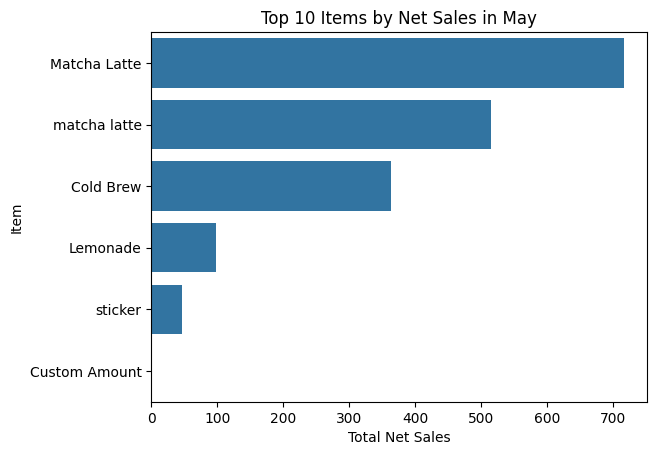

In [94]:
sns.barplot(x=df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10).values, y=df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10).index)
plt.xlabel("Total Net Sales")
plt.ylabel("Item")
plt.title("Top 10 Items by Net Sales in May")
plt.show()